**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4033 - Visión computacional para imágenes y video**

Tecnológico de Monterrey

Prof Gilberto Ochoa Ruiz

**Semana 7**
Image Matching

---

**Equipo 23**

|                 NOMBRE              | MATRÍCULA |
|-------------------------------------|-----------|
| Luis Fernando Caporal Montes de Oca | A01795898 |  
| David Alexis García Espinosa        | A01795178 |
| Jorge Santana Mendoza               | A01376306 |
| José Manuel Romo Peredo             | A01065270 |
| Luis Daniel Ortega Muñoz            | A01795197 |
             

# 9. Image Matching

## Table of Contents
1. [Libraries](#libraries)
2. [ORB Matching](#orb)
3. [SIFT Matching](#sift)
4. [Actividad](#actividad)
5. [Referencias](#referencias)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [28]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## ORB (Oriented FAST and Rotated BRIEF) <a class="anchor" id="orb" ></a>

- Developed at OpenCV labs by Ethan Rublee, Vincent Rabaud, Kurt Konolige, and Gary R. Bradski in 2011
- Efficient and viable alternative to SIFT and SURF (patented algorithms)
- ORB is free to use
- Feature detection
- ORB builds on FAST keypoint detector + BRIEF descriptor

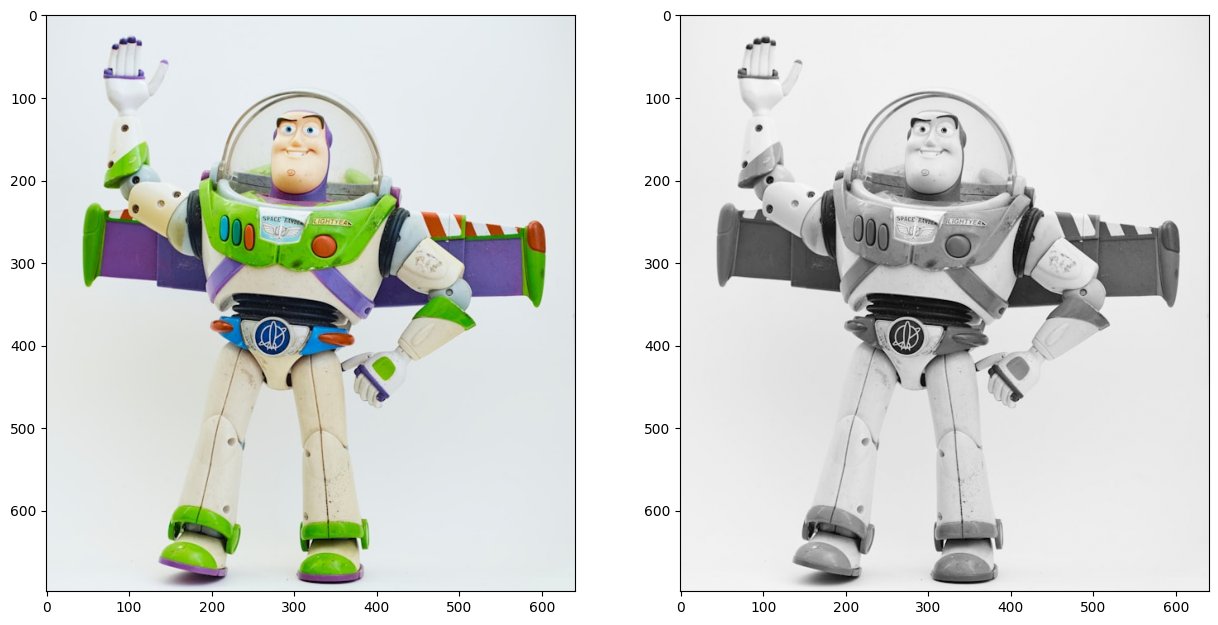

In [5]:
#reading image
img = cv2.imread('data/toy_1.jpg')
img_color = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_color)
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")

### Create test image by adding Scale Invariance and Rotational Invariance

In [6]:
test_image = cv2.pyrDown(img_color)
test_image = cv2.pyrDown(test_image)
num_rows, num_cols = test_image.shape[:2]

rotation_matrix = cv2.getRotationMatrix2D((num_cols/2, num_rows/2), 30, 1)
test_image = cv2.warpAffine(test_image, rotation_matrix, (num_cols, num_rows))

test_gray = cv2.cvtColor(test_image, cv2.COLOR_RGB2GRAY)

### Display traning image and testing image

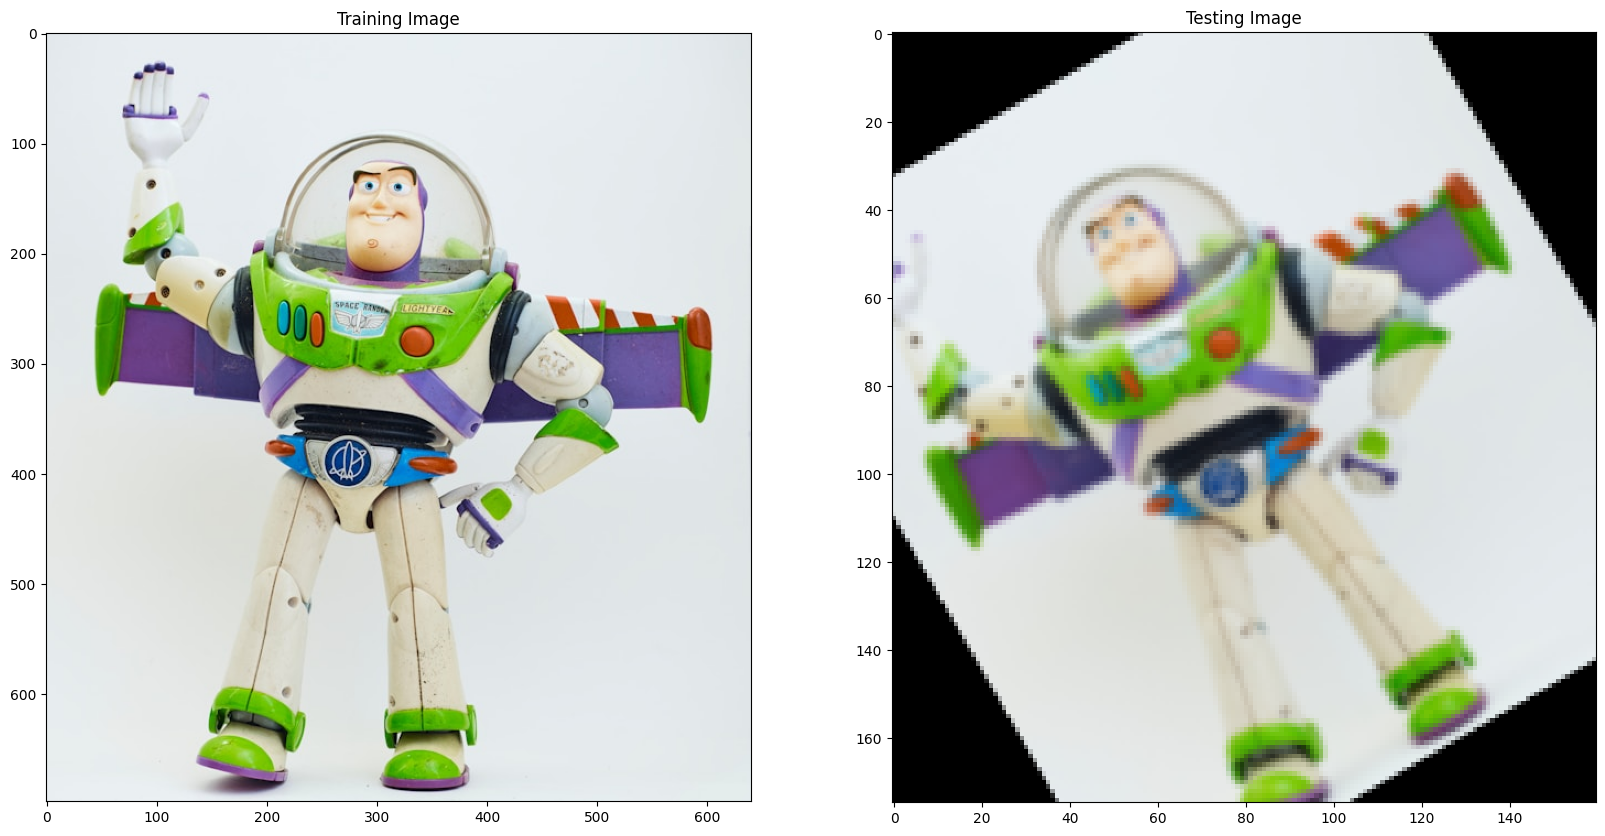

In [7]:
fx, plots = plt.subplots(1, 2, figsize=(20,10))

plots[0].set_title("Training Image")
plots[0].imshow(img_color)

plots[1].set_title("Testing Image")
plots[1].imshow(test_image)

### ORB

In [8]:
orb = cv2.ORB_create()

Number of Keypoints Detected In The Training Image:  500
Number of Keypoints Detected In The Query Image:  333


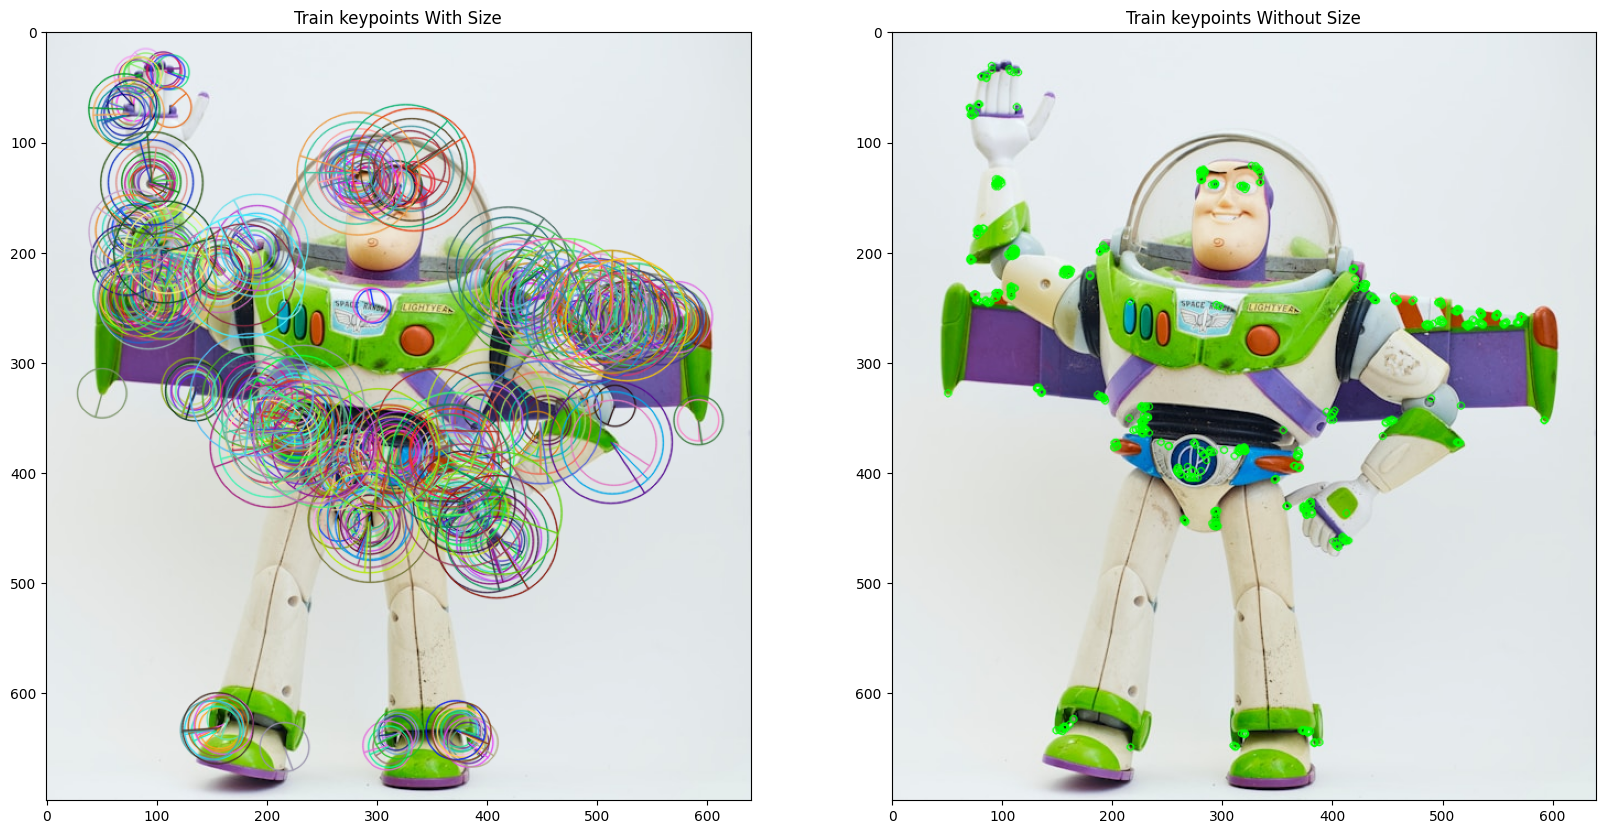

In [9]:
train_keypoints, train_descriptor = orb.detectAndCompute(img_color, None)
test_keypoints, test_descriptor = orb.detectAndCompute(test_gray, None)

keypoints_without_size = np.copy(img_color)
keypoints_with_size = np.copy(img_color)

cv2.drawKeypoints(img_color, train_keypoints, keypoints_without_size, color = (0, 255, 0))

cv2.drawKeypoints(img_color, train_keypoints, keypoints_with_size, flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display image with and without keypoints size
fx, plots = plt.subplots(1, 2, figsize=(20,10))

plots[0].set_title("Train keypoints With Size")
plots[0].imshow(keypoints_with_size, cmap='gray')

plots[1].set_title("Train keypoints Without Size")
plots[1].imshow(keypoints_without_size, cmap='gray')

# Print the number of keypoints detected in the training image
print("Number of Keypoints Detected In The Training Image: ", len(train_keypoints))

# Print the number of keypoints detected in the query image
print("Number of Keypoints Detected In The Query Image: ", len(test_keypoints))

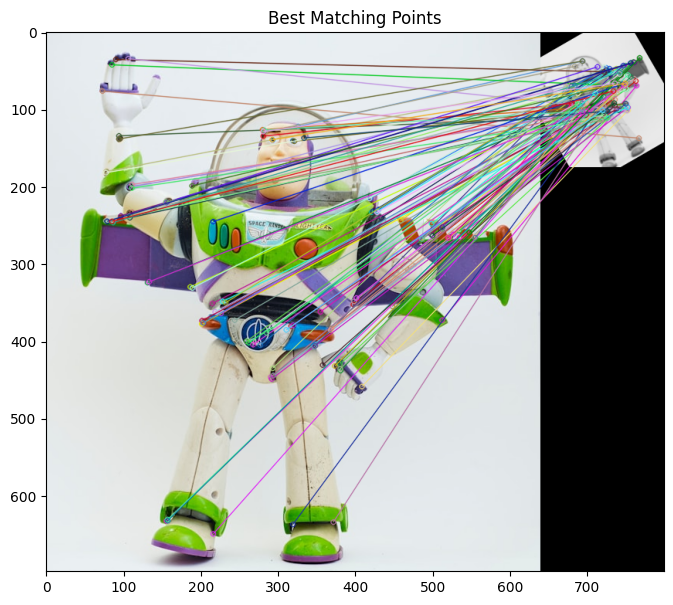


Number of Matching Keypoints Between The Training and Query Images:  113


In [ ]:
# Create a Brute Force Matcher object.
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck = True)

# Perform the matching between the ORB descriptors of the training image and the test image
matches = bf.match(train_descriptor, test_descriptor)

# The matches with shorter distance are the ones we want.
matches = sorted(matches, key = lambda x : x.distance)

result = cv2.drawMatches(img_color, train_keypoints, test_gray, test_keypoints, matches, test_gray, flags = 2)

# Display the best matching points
plt.rcParams['figure.figsize'] = [14.0, 7.0]
plt.title('Best Matching Points')
plt.imshow(result)
plt.show()

# Print total number of matching points between the training and query images
print("\nNumber of Matching Keypoints Between The Training and Query Images: ", len(matches))

## SIFT Matching (Scale Invariant Feature Transform) <a class="anchor" id="sift" ></a>

- Developed by David Lowe in 1999

- Widely used for detecting and describing local features in images

- Patented and therefore not free to use without proper licensing

- Excellent for feature detection and matching

- SIFT is invariant to scale and rotation, and robust to changes in illumination, noise, and minor changes in viewpoint


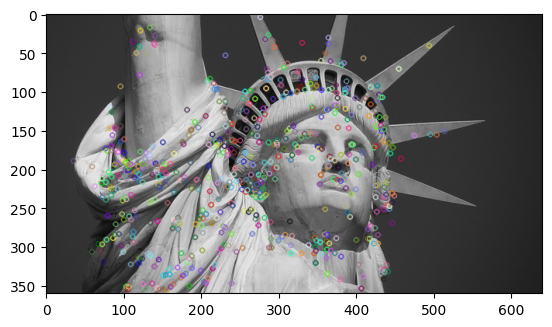

In [24]:
img1 = cv2.imread('data/estatua_1.jpg')
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

#keypoints
sift = cv2.SIFT_create()
keypoints_1, descriptors_1 = sift.detectAndCompute(img1,None)

img_1 = cv2.drawKeypoints(gray1,keypoints_1,img1)
plt.imshow(img_1)

### Matching different images

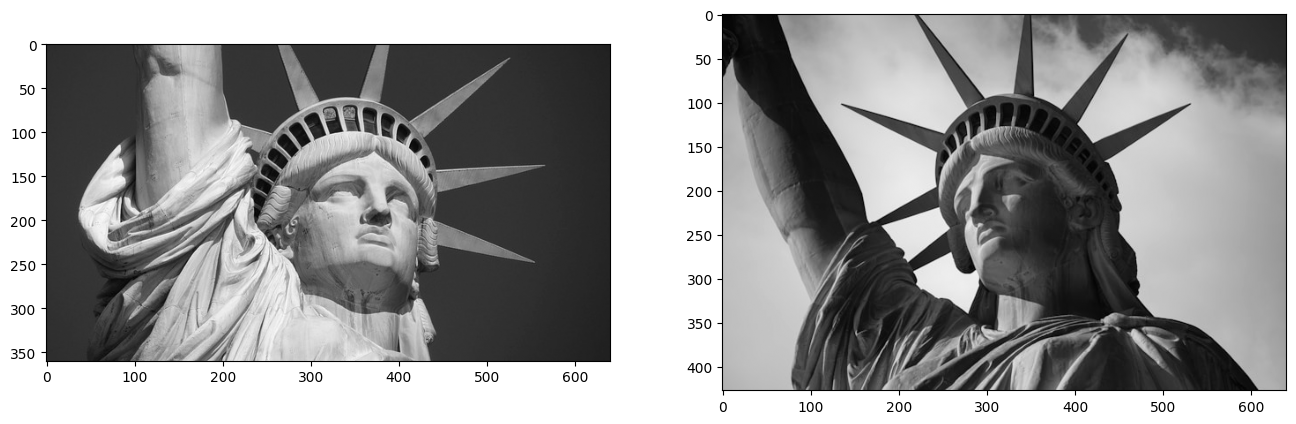

In [25]:
# read images
img1 = cv2.imread('data/estatua_1.jpg')
img2 = cv2.imread('data/estatua_3.jpg')

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

figure, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].imshow(img1, cmap='gray')
ax[1].imshow(img2, cmap='gray')

### Extracting Keypoints with SIFT

In [26]:
#sift
sift = cv2.SIFT_create()

keypoints_1, descriptors_1 = sift.detectAndCompute(img1,None)
keypoints_2, descriptors_2 = sift.detectAndCompute(img2,None)

len(keypoints_1), len(keypoints_2)

(657, 616)

### Feature Matching

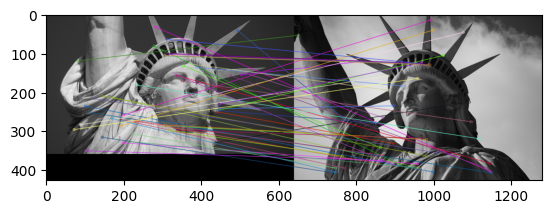

(<matplotlib.image.AxesImage at 0x7b26e5c44ad0>, None)

In [27]:
#feature matching
bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck=True)

matches = bf.match(descriptors_1,descriptors_2)
matches = sorted(matches, key = lambda x:x.distance)

img3 = cv2.drawMatches(img1, keypoints_1, img2, keypoints_2, matches[:50], img2, flags=2)
plt.imshow(img3),plt.show()

In [ ]:
img1 = cv2.imread('data/matching_1.jpg')
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

#keypoints
sift = cv2.SIFT_create()
keypoints_1, descriptors_1 = sift.detectAndCompute(img1,None)

img_1 = cv2.drawKeypoints(gray1,keypoints_1,img1)
plt.imshow(img_1)

In [ ]:
# read images
img1 = cv2.imread('data/matching_1.jpg')
img2 = cv2.imread('data/_3.jpg')

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

figure, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].imshow(img1, cmap='gray')
ax[1].imshow(img2, cmap='gray')

In [ ]:
#sift
sift = cv2.SIFT_create()

keypoints_1, descriptors_1 = sift.detectAndCompute(img1,None)
keypoints_2, descriptors_2 = sift.detectAndCompute(img2,None)

len(keypoints_1), len(keypoints_2)

In [ ]:
#feature matching
bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck=True)

matches = bf.match(descriptors_1,descriptors_2)
matches = sorted(matches, key = lambda x:x.distance)

img3 = cv2.drawMatches(img1, keypoints_1, img2, keypoints_2, matches[:50], img2, flags=2)
plt.imshow(img3),plt.show()

## Actividad <a class="anchor" id="actividad" ></a>

### Descripción de la Actividad

En esta actividad se emplearon dos algoritmos distintos de detección de características: SIFT (Scale-Invariant Feature Transform) y ORB (Oriented FAST and Rotated BRIEF). Ambos métodos permiten identificar puntos clave y descriptores en imágenes para posteriormente realizar emparejamiento entre ellas. Se compararon sus resultados en imágenes con variaciones en iluminación y transformación geométrica.

### Resultados

1. Detección de Características
SIFT (150 características):
Imagen 1 (Referencia): 150 puntos clave
Imagen 2 (Transformada): 50 puntos clave
ORB (Configuración por defecto):
Imagen 1 (Referencia): 500 puntos clave (estimado)
Imagen 2 (Transformada): 500 puntos clave (estimado)
2. Emparejamiento de Características
Para la comparación entre imágenes, se utilizó Brute-Force Matcher (BFMatcher) con diferentes métricas:

SIFT: Se empleó cv2.NORM_L1, adecuado para descriptores de punto flotante.
ORB: Se utilizó cv2.NORM_HAMMING, apropiado para descriptores binarios.
Se aplicó la prueba de razón de Lowe (Ratio Test) para filtrar coincidencias débiles en el caso de SIFT.
3. Visualización de Resultados
SIFT produce menos puntos clave pero de mayor precisión.
ORB detecta más características, pero algunas pueden ser menos discriminativas.
La calidad del emparejamiento mejora al filtrar los resultados con Lowe’s Ratio Test.

###Análisis y Comparación

**Precisión en el Emparejamiento**

- SIFT mostró mayor precisión, especialmente después de aplicar la prueba de razón de Lowe.

- ORB produjo más emparejamientos, pero con mayor cantidad de falsos positivos.
Eficiencia Computacional

- SIFT es más preciso pero computacionalmente más costoso.
ORB es más rápido y ligero, ideal para dispositivos con menos recursos.

###Conclusión:

El experimento mostró que SIFT y ORB ofrecen diferentes ventajas en la detección y emparejamiento de características. Mientras que SIFT proporciona mayor precisión, su costo computacional lo hace menos viable para aplicaciones en tiempo real. En contraste, ORB es significativamente más rápido, aunque menos preciso, lo que lo hace ideal para dispositivos con recursos limitados.

En la práctica, la elección entre SIFT y ORB dependerá del caso de uso. Para aplicaciones en tiempo real, como el seguimiento de objetos en video, ORB es más adecuado debido a su rapidez. Para tareas que requieren alta precisión, como la reconstrucción 3D o el registro de imágenes, SIFT es la mejor opción.

Este ejercicio demuestra la importancia de seleccionar adecuadamente el algoritmo de detección y ajustar sus parámetros para obtener un balance entre precisión y eficiencia en visión por computadora.